In [1]:
from mpi4py import MPI
import gmsh
import numpy as np
from scipy.spatial import cKDTree
import pyvista as pv
from dolfinx import plot

# --- before the refinement loop (rank 0 only collects) ---
h_list, L2_list, L2_fem_list, rL2_list, rL2s_fem_list, H1s_list, rH1s_list = [], [], [], [], [], [], []
# L2_fem_list_pf, rL2s_fem_list_pf, H1s_list_pf, rH1s_list_pf = [], [], [], []
# L2_fem_list_lmbd, rL2s_fem_list_lmbd, H1s_list_lmbd, rH1s_list_lmbd = [], [], [], []

# plotter = pv.Plotter(shape=(2, 4), window_size=(2000, 1000))
N_ref = 10

Lx, Ly = 1.0, 1.0
# y_start, y_end = 0.0, 1.0
# x_start, x_end = 0.25, 0.75


In [2]:
from dolfinx import mesh, fem
import ufl
import numpy as np
from dolfinx.io import gmsh as gmshio
from mpi4py import MPI

# ---------------------------------------------------------------------
# 1. Mesh and tags (same mesh as reference)
# ---------------------------------------------------------------------
ref = 6
filename = f"regular_mesh_{ref}.msh"
msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

tdim = msh.topology.dim  # 2
fdim = tdim - 1          # 1

lc = 1.0 / (2**ref)      # mesh size
h = lc

omega = msh

# ---------------------------------------------------------------------
# 2. Function space (standard CG on the bulk only)
# ---------------------------------------------------------------------
order = 1
V = fem.functionspace(omega, ("Lagrange", order))

# ---------------------------------------------------------------------
# 3. Trial / Test / Solution function
# ---------------------------------------------------------------------
phi = ufl.TestFunction(V)
p = fem.Function(V, name="p")
dp = ufl.TrialFunction(V)

# ---------------------------------------------------------------------
# 4. Coordinates and data
# ---------------------------------------------------------------------
x = ufl.SpatialCoordinate(omega)
# f_m = fem.Constant(omega, 0.0)
# f_m = 2*(x[1] - x[1]**2 + x[0] - x[0]**2)
f_m = -x[1]**2 -2*x[0]**2
def f_callable(x):
    return -x[1]**2 -2*x[0]**2

f = fem.Function(V)
f_func = fem.Function(V)
f_func.interpolate(f_callable)
f.interpolate(f_callable)
# create function
k_m = fem.Function(V, name="kappa")

def k_callable(x):
    # x is array with shape (gdim, N). compute scalar per point, return shape (1,N)
    vals = 2*(x[0])
    return vals[np.newaxis, :]

k_m.interpolate(k_callable)

def k_torch(X):
    # X shape: (Ns, gdim)
    return 2.0 * X[:, 0:1]  # shape (Ns, 1)

kappa = 1.0
# k_m = fem.Constant(omega, kappa)  # bulk permeability

dx = ufl.Measure("dx", domain=omega)

# compute domain bbox to locate sides
coords = omega.geometry.x
xx = coords[:, 0]
yy = coords[:, 1]
xmin, xmax = xx.min(), xx.max()
ymin, ymax = yy.min(), yy.max()

tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# locate boundary facets for bottom (y = ymin) and top (y = ymax)
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
)
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
)

# create meshtags for those Neumann parts (optional — kept for clarity)
indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
values = np.concatenate([
    np.full(bottom_facets.shape, 10, dtype=np.int32),  # bottom tag = 10
    np.full(top_facets.shape,    20, dtype=np.int32),  # top tag    = 20
])
neumann_tags = mesh.meshtags(omega, fdim, indices, values)

# boundary measure (we'll use ds over the whole boundary with conditional g_N)
# dsN = ufl.Measure("ds", domain=omega)  # we integrate g_N over the boundary
dsN = ufl.Measure("ds", domain=omega, subdomain_data=neumann_tags)
g_top = 2 * x[0]**2
g_bottom = 0.0

# Neumann data as conditional on the y coordinate (same as reference)
# g_N = ufl.conditional(
#     ufl.lt(abs(x[1] - ymax), tol),
#     -1.0,                                # top
#     ufl.conditional(
#         ufl.lt(abs(x[1] - ymin), tol),
#         2.0,                             # bottom
#         0.0                              # elsewhere
#     ),
# )

# ---------------------------------------------------------------------
# 5. Weak form (standard Darcy / Poisson form)
# ---------------------------------------------------------------------
a = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * dx
L = f_m * phi * dx
L += g_bottom * phi * dsN(10)
L += g_top * phi * dsN(20)

# Form for assembling (bilinear/trilinear functions expect TrialFunction in a)
A_form = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * dx
b_form = L

# ---------------------------------------------------------------------
# 6. Dirichlet BCs (left/right like reference)
# ---------------------------------------------------------------------
# locate dofs on each side
left_dofs   = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmax, atol=tol))
top_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], ymax, atol=tol))
bottom_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], ymin, atol=tol))

all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))
dof_coords = V.tabulate_dof_coordinates()

p_bc_fun = fem.Function(V)
p_bc_fun.x.array[left_dofs] = 0.0
p_bc_fun.x.array[right_dofs] = dof_coords[right_dofs, 1]**2 / 2.0
# p_bc_fun.x.array[top_dofs] = 0.0
# p_bc_fun.x.array[bottom_dofs] = 0.0

bc = fem.dirichletbc(p_bc_fun, all_dofs)
bcs = [bc]

# ---------------------------------------------------------------------
# 7. Solve linear problem using dolfinx.fem.petsc.LinearProblem
# ---------------------------------------------------------------------
from dolfinx.fem import petsc

linear_problem = petsc.LinearProblem(
    a=A_form,
    L=b_form,
    bcs=bcs,
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "ksp_error_if_not_converged": True,
    },
    petsc_options_prefix="pmix_"
)

p_sol = linear_problem.solve()
p_sol.name = "pressure"

# optionally copy into p Function if you prefer
p.x.array[:] = p_sol.x.array[:]

# ---------------------------------------------------------------------
# 8. Diagnostics
# ---------------------------------------------------------------------
print("DOFs in V:", V.dofmap.index_map.size_global)


Info    : Reading 'regular_mesh_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_6.msh'
DOFs in V: 4225


In [3]:
from dolfinx.io import XDMFFile
import pathlib

outdir = pathlib.Path("result_test_lcg_regular_ex1_linear_k_f")
outdir.mkdir(exist_ok=True)

from dolfinx.io import XDMFFile

# ------------------------------
# 1) Save bulk field p_m on Ω
# ------------------------------
omega_file = outdir / "p_h.xdmf"
with XDMFFile(omega.comm, str(omega_file), "w") as xdmf:
    xdmf.write_mesh(omega)
    xdmf.write_function(p_sol)

In [4]:
# Access mesh geometry
tdim = omega.topology.dim

# Gather coordinates and connectivity
omega_geometry = omega.geometry.x[:,0:2]  # global array of vertex coords
# Build cell->vertex mapping (fast access)
# Using dolfinx.Cell to get connectivity is more robust, but below uses mesh.topology
cells = omega.topology.connectivity(0, tdim)  # vertices -> cells
# Instead get cell->vertex mapping via mesh.topology.index_map?
# Simpler: use mesh.geometry.x with mesh.topology.connectivity(tdim, 0)
ctv = omega.topology.connectivity(tdim, 0)
if ctv is None:
    omega.topology.create_connectivity(tdim, 0)
    ctv = omega.topology.connectivity(tdim, 0)
# ctv.array() gives flattened vertex indices -> need per-cell view
# There's a helper to get cell entity indices
num_cells = omega.topology.index_map(tdim).size_local  # per-rank local count
# We'll iterate over local cells only
local_cells = np.arange(num_cells, dtype=np.int32)

# For evaluating u_h and kappa, we can use u_h.x.array if needed.
# But easier: create a point evaluation lambda to get value at a point
from dolfinx.fem import Function
u_func = p_sol
local_fluxes = {}
V_dofmap = V.dofmap.index_map.local_range  # not directly used; we'll query dofs per cell

# Get dof indices per cell
# Using dolfinx.fem.locate_dofs_topological is one option, but below we get cell_dofs
dofmap = V.dofmap
# But to avoid uncertain reshape semantics, use mesh.topology.connectivity(tdim, 0).entities
# Simpler robust approach: use dolfinx.mesh.cells() to get local cells vertex indices
try:
    from dolfinx.mesh import cells as dolfinx_cells
    local_cell_vertices = dolfinx_cells(mesh)
except Exception:
    # fallback: create by slicing connectivity
    # arr = ctv.array
    # local_cell_vertices = arr.reshape((-1, 3))
    local_cell_vertices = np.array([ctv.links(c) for c in range(ctv.num_nodes)])

In [5]:
tdim = omega.topology.dim
omega.topology.create_connectivity(tdim, tdim - 1)
omega.topology.create_connectivity(tdim - 1, tdim)

c2f = omega.topology.connectivity(tdim, tdim - 1)
f2c = omega.topology.connectivity(tdim - 1, tdim)

num_cells = omega.topology.index_map(tdim).size_local

local_cell_adjacent = [[] for _ in range(num_cells)]

for c in range(num_cells):
    neighbors = set()
    for ff in c2f.links(c):
        for cc in f2c.links(ff):
            if cc != c:
                neighbors.add(int(cc))
    local_cell_adjacent[c] = list(neighbors)


In [6]:
#facet vertices
tdim = omega.topology.dim
fdim = tdim - 1

# Make sure facet -> vertex connectivity exists
if omega.topology.connectivity(fdim, 0) is None:
    omega.topology.create_connectivity(fdim, 0)

f2v = omega.topology.connectivity(fdim, 0)

num_facets = omega.topology.index_map(fdim).size_local
local_facets = np.arange(num_facets, dtype=np.int32)

facet_vertices = []
facet_coords = []

x = omega.geometry.x  # global vertex coordinates

for ff in local_facets:
    verts = f2v.links(ff)          # vertex indices of facet f
    coords = x[verts]             # coordinates of those vertices

    facet_vertices.append(verts)
    facet_coords.append(coords)


In [7]:

import numpy as np
from collections import defaultdict

def compute_cell_subdomains_from_connectivity(
    local_cell_vertices,
    omega_geometry,
    n_per_dim,
    x0=0.0, x1=1.0,
    y0=0.0, y1=1.0,
):
    """
    Connectivity-based subdomain adjacency detection.
    Works for structured triangular meshes.

    Returns:
        cell_subdomain : list of lists
            [own_subdomain, adj1, adj2, ...]
    """

    m = n_per_dim
    dx = (x1 - x0) / m
    dy = (y1 - y0) / m

    n_cells = len(local_cell_vertices)

    # -------------------------------------------------
    # 1. Compute centroid-based OWNERSHIP only
    # -------------------------------------------------
    centroids = np.array([
        omega_geometry[verts].mean(axis=0)
        for verts in local_cell_vertices
    ])

    own_sub = []

    for x_c, y_c in centroids:
        ix = int((x_c - x0) / dx)
        iy = int((y_c - y0) / dy)

        ix = max(0, min(m - 1, ix))
        iy = max(0, min(m - 1, iy))

        own_sub.append(iy * m + ix)

    # -------------------------------------------------
    # 2. Build edge-to-cell map
    # -------------------------------------------------
    edge_map = defaultdict(list)

    for cell_id, verts in enumerate(local_cell_vertices):
        nv = len(verts)
        for k in range(nv):
            v0 = verts[k]
            v1 = verts[(k + 1) % nv]

            edge = tuple(sorted((v0, v1)))
            edge_map[edge].append(cell_id)

    # -------------------------------------------------
    # 3. Detect adjacency via shared edges
    # -------------------------------------------------
    cell_subdomain = []

    for cell_id in range(n_cells):

        subs = [own_sub[cell_id]]

        verts = local_cell_vertices[cell_id]
        nv = len(verts)

        for k in range(nv):
            v0 = verts[k]
            v1 = verts[(k + 1) % nv]
            edge = tuple(sorted((v0, v1)))

            neighbors = edge_map[edge]

            for nb in neighbors:
                if nb == cell_id:
                    continue

                nb_sub = own_sub[nb]
                if nb_sub != own_sub[cell_id] and nb_sub not in subs:
                    subs.append(nb_sub)

        cell_subdomain.append(subs)

    return cell_subdomain


num_subdomains = 1
cell_subdomain = compute_cell_subdomains_from_connectivity(local_cell_vertices, omega_geometry, int(np.sqrt(num_subdomains)))

In [8]:
from tqdm import tqdm
import basix
from dolfinx import default_scalar_type, mesh as dmesh
import math

def precompute_cell_flux_and_source():
    """
    Precompute, for each cell K:
        int_qcg[K] = ∫_{∂K} q_CG · n ds
        int_f[K]   = ∫_K f dx
    where q_CG = -k_m * grad(p_sol).

    Returns:
        cell_flux: dict mapping cell_idx -> (int_qcg, int_f)
    """
    cell_flux = {}

    gdim = omega_geometry.shape[1]

    # 1-cell template mesh
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
    dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)

    local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)

    tdim = local_mesh.topology.dim

    V_loc = fem.functionspace(local_mesh, ("CG", order + 1, (gdim,)))
    P_loc = fem.functionspace(local_mesh, ("CG", order))

    p_K = fem.Function(P_loc)
    k_m_loc = fem.Function(P_loc)
    f_m_loc = fem.Function(P_loc)

    # Local DOFs for the single template cell
    local_dofs = P_loc.dofmap.cell_dofs(0)

    n_K = ufl.FacetNormal(local_mesh)
    q_CG = -k_m_loc * ufl.grad(p_K)

    ds = ufl.ds(domain=local_mesh)
    dx = ufl.dx(domain=local_mesh)

    for cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
        coords = omega_geometry[cell_verts]
        # update geometry
        local_mesh.geometry.x[:, :gdim] = coords

        # copy global DOFs into local functions
        global_dofs = V.dofmap.cell_dofs(cell_idx)
        p_K.x.array[local_dofs] = p_sol.x.array[global_dofs]
        k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]
        f_m_loc.x.array[local_dofs] = f.x.array[global_dofs]

        p_K.x.scatter_forward()
        k_m_loc.x.scatter_forward()
        f_m_loc.x.scatter_forward()

        # assemble cell-level quantities
        int_qcg = fem.assemble_scalar(fem.form(ufl.dot(q_CG, n_K) * ds))
        int_f   = fem.assemble_scalar(fem.form(f_m_loc * dx))

        cell_flux[cell_idx] = (float(int_qcg), float(int_f))

    return cell_flux

cell_flux = precompute_cell_flux_and_source()

100%|██████████| 8192/8192 [00:27<00:00, 292.76it/s]


In [9]:
def precompute_interface_cg_fluxes():
    """
    Precompute ∫_e q_CG · n_K ds for every cell edge.
    Returns:
        cg_flux[(cell_idx, local_edge_id)] = float
    """

    cg_flux = {}

    gdim = omega_geometry.shape[1]

    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
    dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)

    local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)

    tdim = local_mesh.topology.dim
    fdim = tdim - 1

    local_mesh.topology.create_connectivity(tdim, fdim)
    local_mesh.topology.create_connectivity(fdim, tdim)
    local_mesh.topology.create_connectivity(0, fdim)
    local_mesh.topology.create_connectivity(fdim, 0)

    num_facets = local_mesh.topology.index_map(fdim).size_local

    facets = np.arange(num_facets, dtype=np.int32)
    facet_values = np.arange(num_facets, dtype=np.int32)
    facet_tags = mesh.meshtags(local_mesh, fdim, facets, facet_values)

    ds = ufl.Measure("ds", domain=local_mesh, subdomain_data=facet_tags)

    V_loc = fem.functionspace(local_mesh, ("CG", order + 1, (gdim,)))
    P_loc = fem.functionspace(local_mesh, ("CG", order))

    p_K = fem.Function(P_loc)
    k_m_loc = fem.Function(P_loc)

    local_dofs = P_loc.dofmap.cell_dofs(0)

    n_K = ufl.FacetNormal(local_mesh)
    q_CG = -k_m_loc * ufl.grad(p_K)

    # Build edge mapping
    v_to_f = local_mesh.topology.connectivity(0, fdim)
    f_to_v = local_mesh.topology.connectivity(fdim, 0)

    edge_to_facet = {}
    for v0 in range(3):
        for fct in v_to_f.links(v0):
            verts = f_to_v.links(fct)
            for v1 in verts:
                if v1 != v0:
                    edge_to_facet[(v0, v1)] = fct

    edge_indices_loc = [(0, 1), (1, 2), (2, 0)]

    for cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):

        coords = omega_geometry[cell_verts]
        local_mesh.geometry.x[:, :gdim] = coords

        global_dofs = V.dofmap.cell_dofs(cell_idx)

        p_K.x.array[local_dofs] = p_sol.x.array[global_dofs]
        k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]

        p_K.x.scatter_forward()
        k_m_loc.x.scatter_forward()

        for edge_loc, (v0, v1) in enumerate(edge_indices_loc):
            facet_id = edge_to_facet[(v0, v1)]

            value = fem.assemble_scalar(
                fem.form(ufl.dot(q_CG, n_K) * ds(facet_id))
            )

            cg_flux[(cell_idx, edge_loc)] = value

    return cg_flux

cg_flux = precompute_interface_cg_fluxes()

100%|██████████| 8192/8192 [00:45<00:00, 179.48it/s]


In [10]:
LCE_CG = []
indices = []

LCE_CG_int = []
indices_int = []
for local_cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
    # cell_verts are global vertex indices
    coords = omega_geometry[cell_verts]  # shape (3,2)
    sd = cell_subdomain[local_cell_idx][0]
    centroid = np.mean(coords, axis=0).reshape(1,-1)[0]

    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)

    gdim = coords.shape[1]
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))

    local_mesh = dmesh.create_mesh(
        MPI.COMM_SELF,
        loc_cells,
        coord_el,   # <-- this is the required "e" argument
        coords
    )
    cell_dofs = V.dofmap.cell_dofs(local_cell_idx)
    # -------------------------------------------------
    # 2. Local vector CG2 space for r_θ
    # -------------------------------------------------
    # Vector-valued CG2 (shape=(gdim,))
    V_loc = fem.functionspace(local_mesh, ("CG", order+1, (gdim,)))
    # r_loc = fem.Function(V_loc)

    # -------------------------------------------------
    # 3. Interpolate NN into r_loc via dof coordinates
    # -------------------------------------------------
    x_loc = V_loc.tabulate_dof_coordinates()[:,0:2]  # (Ndofs, gdim)

    # r_vals_torch = net(x_loc_torch)                             # (Ndofs, gdim)
    # r_vals = r_vals_torch.detach().cpu().numpy().reshape(-1)

    # assign to local FEM function
    # r_loc.x.array[:] = r_vals.astype(default_scalar_type)

    # -------------------------------------------------
    # 4. Compute ∫_{∂D_j} r_θ · n ds on local mesh
    # -------------------------------------------------
    n_K = ufl.FacetNormal(local_mesh)
    # int_r_form = fem.form(ufl.dot(r_loc, n_K) * ufl.ds)

    edge_indices = [(0, 1), (1, 2), (2, 0)]

    num_sub = 3 #sub integral section

    for (i0, i1) in edge_indices:
        x0 = coords[i0]
        x1 = coords[i1]
        t = x1 - x0
        L = np.linalg.norm(t)
        if L <= 0:
            continue

        n_edge = (np.stack([t[1], -t[0]]) / L)
        midpoint = 0.5 * (x0 + x1)
        if np.dot(n_edge, centroid - midpoint) > 0:
            n_edge = -n_edge
    # int_r_local = fem.assemble_scalar(int_r_form)

    # -------------------------------------------------
    # 5. Combine with q_cg and f (precomputed per cell)
    # -------------------------------------------------
    P_loc = fem.functionspace(local_mesh, ("CG", order))
    p_K = fem.Function(P_loc)

    # DOFs on this cell in the global space
    global_dofs = V.dofmap.cell_dofs(local_cell_idx)

    # DOFs on the (only) cell in the local space
    local_dofs = P_loc.dofmap.cell_dofs(0)

    p_K.x.array[local_dofs] = p_sol.x.array[global_dofs]
    p_K.x.scatter_forward()

    k_m_loc = fem.Function(P_loc)
    k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]

    q_CG = -k_m_loc * ufl.grad(p_K)
    int_qcg = fem.assemble_scalar(
                fem.form(ufl.dot(q_CG, n_K) * ufl.ds(domain=local_mesh))
            )   # ∫_{∂D_j} q_cg · n
    
    f_m_loc = fem.Function(P_loc)
    f_m_loc.x.array[local_dofs] = f.x.array[global_dofs]
    f_m_loc.x.scatter_forward()
    int_f   = fem.assemble_scalar(fem.form(f_m_loc * ufl.dx(domain=local_mesh)))       # ∫_{D_j} f

    LCE_CG.append(int_qcg - int_f)
    indices.append(local_cell_idx)

    left_dofs_P = fem.locate_dofs_geometrical(
        P_loc, lambda x: np.isclose(x[0], xmin, atol=tol)
    )
    right_dofs_P = fem.locate_dofs_geometrical(
        P_loc, lambda x: np.isclose(x[0], xmax, atol=tol)
    )

    if (len(left_dofs_P) == 0) and (len(right_dofs_P) == 0):
        LCE_CG_int.append(int_qcg - int_f)
        indices_int.append(local_cell_idx)

100%|██████████| 8192/8192 [00:54<00:00, 149.40it/s]


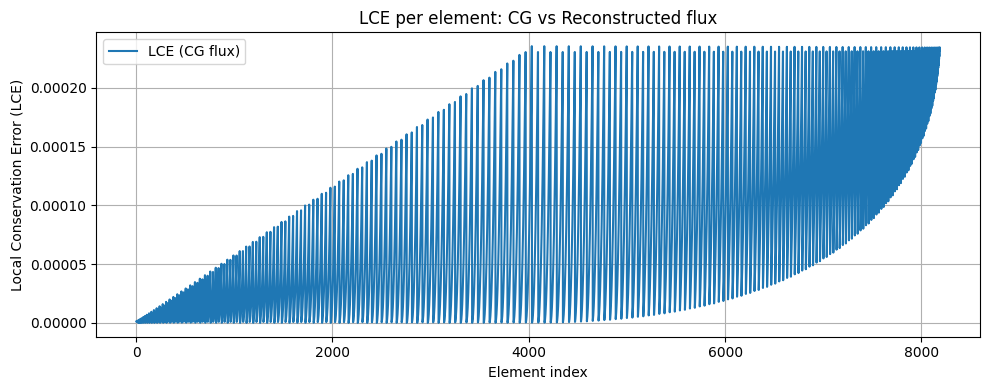

In [11]:
import matplotlib.pyplot as plt
indices_plot = np.array(indices_int, dtype=int)
LCE_CG_plot = np.array(LCE_CG_int, dtype=float)

# plot
plt.figure(figsize=(10,4))
plt.plot(indices_plot, np.abs(LCE_CG_plot), label="LCE (CG flux)")
plt.xlabel("Element index")
plt.ylabel("Local Conservation Error (LCE)")
plt.title("LCE per element: CG vs Reconstructed flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
# out_path = "/mnt/data/lce_plot.png"
# plt.savefig(out_path)
plt.show()


In [12]:
from dolfinx import geometry
def eval_scalar_at_point(u, point):
    """
    Evaluate a scalar dolfinx.fem.Function `u` at a single physical point.

    Parameters
    ----------
    u : dolfinx.fem.Function or float/int
    point : sequence of length mesh.dim

    Returns
    -------
    float
    """
    # allow plain scalars
    if isinstance(u, (float, int, np.floating, np.integer, np.float64)):
        return float(u)
    point = np.asarray(point)
    if point.ndim == 1:
        point = point.reshape(-1, 1)
    V = u.function_space
    mesh = V.mesh
    tdim = mesh.topology.dim
    gdim = mesh.geometry.dim

    # X = np.asarray(point, dtype=np.float64).reshape(1, -1)  # shape (1, dim)
    _gdim, N = point.shape
    if _gdim != gdim:
        raise ValueError(f"Point array has gdim={_gdim}, expected {gdim}")

    # dolfinx expects 3D coordinates; pad in 2D
    if gdim == 2:
        X = np.column_stack([point.T, np.zeros(N, dtype=np.float64)])  # (N, 3)
    elif gdim == 3:
        X = point.T.copy()                                             # (N, 3)
    else:
        raise ValueError(f"Unsupported geometric dimension gdim={gdim}")

    # 1) bounding-box tree + collision test
    bbt = geometry.bb_tree(mesh, tdim)
    cands = geometry.compute_collisions_points(bbt, X)
    hits = geometry.compute_colliding_cells(mesh, cands, X)

    # pick first hit if any
    cell = -1
    links = hits.links(0)
    if len(links) > 0:
        cell = int(links[0])

    # 2) fallback: nearest entity (robust for boundary points / tiny roundoff)
    if cell == -1:
        mid_tree = geometry.create_midpoint_tree(
            mesh, tdim,
            np.arange(mesh.topology.index_map(tdim).size_local, dtype=np.int32)
        )
        nearest = geometry.compute_closest_entity(bbt, mid_tree, mesh, X)
        cell = int(nearest[0])

    # 3) Evaluate using dolfinx Function.eval
    # Try the common signature that returns an array: val = u.eval(X, cells)
    try:
        vals = np.asarray(u.eval(X, np.array([cell], dtype=np.int32))).ravel()
        return float(vals[0])
    except Exception:
        # Alternative signature: u.eval(values_buffer, X, cell)
        # Prepare buffer of correct size (value_size per point)
        vsize = getattr(u, "value_size", 1)
        buf = np.zeros((vsize, 1), dtype=np.float64) if vsize > 1 else np.zeros(1, dtype=np.float64)
        try:
            # note: some dolfinx versions expect (buf, X, cell)
            u.eval(buf, X, cell)
            return float(np.asarray(buf).ravel()[0])
        except Exception as e:
            raise RuntimeError(f"Failed to evaluate Function at point {point}: {e}")

In [ ]:
ref_grads = np.array([[-1.0, -1.0],[1.0, 0.0],[0.0, 1.0]])
elem_grad_u = {}
elem_area = {}
elem_kappa_cent = {}
from tqdm import tqdm

import basix
coef_glob = {i: [] for i in range(len(omega.geometry.x))}
dict_sig ={}
dict_mu = {}
bb = geometry.bb_tree(omega, omega.topology.dim)

import matplotlib.pyplot as plt
from dolfinx import mesh as dmesh
# geometry + local cell vertices
# geometry = mesh.geometry.x.copy()
# local_cell_vertices = dolfinx_cells(mesh)
num_local_cells = local_cell_vertices.shape[0]

# map vertex -> adjacent local cells
vertex_to_cells = {}
for local_cell_idx, verts in enumerate(local_cell_vertices):
    for v in verts:
        vertex_to_cells.setdefault(int(v), []).append(int(local_cell_idx))

# compute element-wise gradients (P1)
dofmap = V.dofmap

# Ensure we have cell–facet connectivity
omega.topology.create_connectivity(tdim, fdim)
c2f = omega.topology.connectivity(tdim, fdim)

# compute LCEs per vertex (control-volume)
vertex_ids = sorted(list(vertex_to_cells.keys()))
LCE_CG = []
LCE_rec = []
indices = []

LCE_CG_int = []
LCE_rec_int = []
indices_int = []

num_dofs = V.dofmap.index_map.size_global
coef_glob = {i: [] for i in range(num_dofs)}

# global broken space for reconstructed flux
Q_rec_global = fem.functionspace(omega, ("DG", order + 1, (gdim,)))
q_rec_global = fem.Function(Q_rec_global)

# convenient 2D view for blocked vector assignment
q_rec_global_arr = q_rec_global.x.array.reshape((-1, gdim))

# coordinates of all global DG dofs
Q_rec_coords = Q_rec_global.tabulate_dof_coordinates()
# Iterate local cells
for local_cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
    # cell_verts are global vertex indices
    coords = omega_geometry[cell_verts]  # shape (3,2)
    centroid = np.mean(coords, axis=0).reshape(1,-1)

    loc_cells = np.array([local_cell_idx], dtype=np.int32)

    gdim = coords.shape[1]
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))

    # ---------------------------------------------------------------------
    # local submesh from selected cells
    # ---------------------------------------------------------------------
    local_mesh, cell_map, vertex_map, geom_map = dmesh.create_submesh(omega, tdim, loc_cells)

    omega.topology.create_connectivity(tdim, fdim)
    omega.topology.create_connectivity(fdim, 0)
    local_mesh.topology.create_connectivity(fdim, 0)

    # for a single-cell submesh -> local cell 0
    parent_cell = cell_map.sub_topology_to_topology(
        np.array([0], dtype=np.int32), False
    )[0]

    # ---------------------------------------------------------------------
    # Build a quick lookup: parent facet id -> parent Neumann tag value
    # ---------------------------------------------------------------------
    parent_facet_to_tag = {}
    for gf, val in zip(neumann_tags.indices, neumann_tags.values):
        parent_facet_to_tag[int(gf)] = int(val)

    # ---------------------------------------------------------------------
    # Match each local facet to its parent facet, then copy the tag
    # If parent facet is not in neumann_tags, assign default value other_tag
    # ---------------------------------------------------------------------
    local_facets = []
    local_values = []

    other_tag = 0   # interior / untagged / not-on-Neumann-boundary

    for lf in range(local_mesh.topology.index_map(fdim).size_local):
        # vertices of local facet in local numbering
        lf_vertices_local = local_mesh.topology.connectivity(fdim, 0).links(lf)

        # map local-facet vertices -> parent-mesh vertex numbering
        lf_vertices_parent = np.sort(
            vertex_map.sub_topology_to_topology(
                np.asarray(lf_vertices_local, dtype=np.int32), False
            )
        )

        matched_parent_facet = None
        for gf in omega.topology.connectivity(tdim, fdim).links(parent_cell):
            gf_vertices = np.sort(omega.topology.connectivity(fdim, 0).links(gf))
            if np.array_equal(lf_vertices_parent, gf_vertices):
                matched_parent_facet = int(gf)
                break

        if matched_parent_facet is None:
            raise RuntimeError(f"Could not match local facet {lf} to a parent facet")

        # copy parent tag if present, otherwise default
        tag_value = parent_facet_to_tag.get(matched_parent_facet, other_tag)

        local_facets.append(lf)
        local_values.append(tag_value)

    # ---------------------------------------------------------------------
    # Create local facet meshtags
    # ---------------------------------------------------------------------
    local_facets = np.array(local_facets, dtype=np.int32)
    local_values = np.array(local_values, dtype=np.int32)

    # sort by facet index before meshtags
    perm = np.argsort(local_facets)
    local_facets = local_facets[perm]
    local_values = local_values[perm]

    local_facet_tags = mesh.meshtags(
        local_mesh,
        fdim,
        local_facets,
        local_values,
    )
    cell_dofs = V.dofmap.cell_dofs(local_cell_idx)

    Sigma_loc = fem.functionspace(local_mesh, ("RT", order)) 
    mu_loc = fem.functionspace(local_mesh, ("CG", order)) #mu_loc -> mu, nu

    RT = basix.ufl.element("RT", local_mesh.basix_cell(), order)
    # P2_vec = basix.ufl.element(
    #             "Lagrange",
    #             local_mesh.basix_cell(),
    #             2,                  
    #             shape=(2,)          
    #         )
    CG = basix.ufl.element("Lagrange", local_mesh.basix_cell(), order)
    # W_el = basix.ufl.mixed_element([P2_vec, CG])
    W_el = basix.ufl.mixed_element([RT, CG])

    W = fem.functionspace(local_mesh, W_el)

    x_loc = ufl.SpatialCoordinate(local_mesh)
    # f_loc = x_loc[1]
    f_loc = -x_loc[1]**2 -2*x_loc[0]**2

    # ================= trial and test functions =================
    tau, nu = ufl.TestFunctions(W)
    sig, mu = ufl.TrialFunctions(W)

    # Measures and normal
    tdim = local_mesh.topology.dim
    fdim = tdim - 1
    dx = ufl.Measure("dx", domain=local_mesh)
    x = ufl.SpatialCoordinate(local_mesh)

    # ---------------------------------------------------------------------
    # local copy of p on local_mesh in CG1
    # ---------------------------------------------------------------------
    p_loc = fem.Function(mu_loc)

    Xdofs = mu_loc.tabulate_dof_coordinates()          # (ndofs, gdim)
    pts = np.zeros((Xdofs.shape[0], 3), dtype=np.float64)
    pts[:, :Xdofs.shape[1]] = Xdofs

    from dolfinx import geometry

    # centroid -> shape (1, 3)
    c = np.zeros((1, 3), dtype=np.float64)
    c[0, :gdim] = np.mean(coords, axis=0)

    cands = geometry.compute_collisions_points(bb, c)
    colliding = geometry.compute_colliding_cells(omega, cands, c)

    links = colliding.links(0)
    assert len(links) > 0, "Centroid not found in any cell (unexpected)."
    cell_id = int(links[0])

    cells = np.full((pts.shape[0],), cell_id, dtype=np.int32)

    vals = p_sol.eval(pts, cells)
    k_m_loc_val = k_m.eval(pts, cells)

    p_loc.x.array[:] = vals.reshape(-1)

    k_m_loc = fem.Function(mu_loc)
    k_m_loc.x.array[:] = k_m_loc_val.reshape(-1)

    dsN_loc = ufl.Measure("ds", domain=local_mesh, subdomain_data=local_facet_tags)

    # Neumann data
    g_bottom = fem.Constant(local_mesh, default_scalar_type(0.0))
    g_top = 2 * x[0]**2

    # ---------------------------------------------------------------------
    # 2. Bulk mixed weak form on local patch
    # ---------------------------------------------------------------------
    a_m = (
        ufl.inner(sig, tau)
        - k_m_loc * mu * ufl.div(tau)
        + nu * ufl.div(sig)
    ) * dx

    L_m = (
        k_m_loc * ufl.inner(ufl.grad(p_loc), tau)
        + f_loc * nu
    ) * dx

    # Add Neumann contribution to pressure equation
    # (this enters the scalar/test-function part, i.e. with nu)
    # L_m += g_bottom * nu * dsN_loc(10)
    # L_m += g_top * nu * dsN_loc(20)

    # ---------------------------------------------------------------------
    # 3. Dirichlet BCs on pressure subspace W.sub(1)
    #    Match the first code:
    #      - left boundary:  p = 0
    #      - right boundary: p = y/2
    #      - optionally enforce one extra dof value from coef_glob
    # ---------------------------------------------------------------------
    mu_sub = W.sub(1)
    Q, collapse_map = mu_sub.collapse()

    # locate dofs consistently between subspace and collapsed space
    left_dofs_mu, left_dofs_Q = fem.locate_dofs_geometrical(
        (mu_sub, Q), lambda x: np.isclose(x[0], xmin, atol=tol)
    )
    right_dofs_mu, right_dofs_Q = fem.locate_dofs_geometrical(
        (mu_sub, Q), lambda x: np.isclose(x[0], xmax, atol=tol)
    )
    dofs_mu_Q = fem.locate_dofs_geometrical(
        (mu_sub, Q),
        lambda x: np.isclose(x[0], xmin, atol=tol) | np.isclose(x[0], xmax, atol=tol)
    )

    # BC values on collapsed pressure space Q
    p_bc_fun = fem.Function(Q)
    dof_coords_Q = Q.tabulate_dof_coordinates()

    # left: 0, right: y/2
    p_bc_fun.x.array[left_dofs_Q] = 0.0
    p_bc_fun.x.array[right_dofs_Q] = 0.0

    # optionally add one extra prescribed dof from coef_glob, exactly as in first code
    local_i_select = []
    gd_select = []
    for local_i, gd in enumerate(cell_dofs):
        if len(coef_glob[gd]) != 0:
            local_i_select.append(local_i)
            gd_select.append(gd)

    if len(local_i_select) != 0:
        p_bc_fun.x.array[local_i_select[0]] = float(coef_glob[gd_select[0]][-1])

        all_dofs_mu = [
            np.concatenate(
                [dofs_mu_Q[0], np.array([collapse_map[local_i_select[0]]], dtype=np.int32)]
            ),
            np.concatenate(
                [dofs_mu_Q[1], np.array([local_i_select[0]], dtype=np.int32)]
            ),
        ]
    else:
        all_dofs_mu = dofs_mu_Q

    bc = fem.dirichletbc(p_bc_fun, all_dofs_mu, mu_sub)
    bcs = [bc]


    # ---------------------------------------------------------------------
    # 7. Solve linear problem using dolfinx.fem.petsc.LinearProblem
    # ---------------------------------------------------------------------
    from dolfinx.fem import petsc

    linear_problem = petsc.LinearProblem(
        a=a_m,
        L=L_m,
        bcs=bcs,
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "ksp_error_if_not_converged": True,
        },
        petsc_options_prefix="pmix_"
    )

    # sig, mu = linear_problem.solve()
    wh = linear_problem.solve()
    W_sol = wh.function_space
    sig = wh.sub(0).collapse()
    mu  = wh.sub(1).collapse()
    # sig.name = "sig"
    # mu.name = "mu"
    # dict_sig[local_cell_idx] = sig
    # dict_mu[local_cell_idx] = mu
    
    for local_i, gd in enumerate(cell_dofs):
        coef_glob[gd].append(mu.x.array[local_i])

    flux_sum_CG = 0.0
    flux_sum_rec = 0.0
    source_sum = 0.0
    coords = omega_geometry[cell_verts]
    centroid = np.mean(coords, axis=0).reshape(1,-1)

    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)

    gdim = coords.shape[1]
    # coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))

    # local_mesh = mesh.create_mesh(
    #     MPI.COMM_SELF,
    #     loc_cells,
    #     coord_el,   # <-- this is the required "e" argument
    #     coords
    # )

    V_loc = fem.functionspace(local_mesh, ("CG", order))
    p_K = fem.Function(V_loc)

    # DOFs on this cell in the global space
    global_dofs = V.dofmap.cell_dofs(local_cell_idx)

    # DOFs on the (only) cell in the local space
    local_dofs = V_loc.dofmap.cell_dofs(0)

    p_K.x.array[local_dofs] = p_sol.x.array[global_dofs]
    p_K.x.scatter_forward()

    n_K = ufl.FacetNormal(local_mesh)

    # k_m can be a scalar or UFL expression; if it's a Function on the global mesh
    # and varies per cell, you'd restrict it similarly to p_K
    q_CG = -k_m_loc * ufl.grad(p_K)

    flux_sum_CG = fem.assemble_scalar(
        fem.form(ufl.dot(q_CG, n_K) * ufl.ds(domain=local_mesh))
    )

    q_rec = sig
    Q_loc = fem.functionspace(local_mesh, ("RT", order+1))
    # Q_loc = fem.functionspace(
    #             local_mesh,
    #             ("Lagrange", 2, (local_mesh.geometry.dim,))
    #         )
    q_rec_K = fem.Function(Q_loc)

    q_rec_K.x.array[:] = q_rec.x.array[:]
    q_rec_K.x.scatter_forward()

    # global DG dofs on this parent cell
    gdofs = Q_rec_global.dofmap.cell_dofs(local_cell_idx)

    # coordinates of those global DG dofs
    x_dofs = Q_rec_coords[gdofs][:,0:2]

    # pad to 3D for eval
    pts = np.zeros((x_dofs.shape[0], 3), dtype=np.float64)
    pts[:, :gdim] = x_dofs

    # evaluate local reconstructed flux on the single local cell (cell 0)
    vals = q_rec.eval(pts, np.zeros(x_dofs.shape[0], dtype=np.int32))

    # store into the global broken DG field
    q_rec_global_arr[gdofs, :] = vals
    
    flux_sum_rec = fem.assemble_scalar(
        fem.form(ufl.dot(q_rec_K, n_K) * ufl.ds(domain=local_mesh))
    )

    if f is not None:
        f_m_loc = fem.Function(V_loc)
        f_m_loc.x.array[local_dofs] = f.x.array[global_dofs]
        f_m_loc.x.scatter_forward()
        source_sum = fem.assemble_scalar(fem.form(f_m_loc * ufl.dx(domain=local_mesh)))
    LCE_CG.append(flux_sum_CG - source_sum)
    LCE_rec.append(flux_sum_rec - source_sum)
    indices.append(local_cell_idx)

    if (len(left_dofs_Q) == 0) and (len(right_dofs_Q) == 0):
        LCE_CG_int.append(flux_sum_CG - source_sum)
        LCE_rec_int.append(flux_sum_rec - source_sum)
        indices_int.append(local_cell_idx)
        
q_rec_global.x.scatter_forward()
    
indices_plot = np.array(indices_int, dtype=int)
LCE_CG_plot = np.array(LCE_CG_int, dtype=float)
LCE_rec_plot = np.array(LCE_rec_int, dtype=float)




  0%|          | 0/8192 [00:00<?, ?it/s]

  0%|          | 0/8192 [00:00<?, ?it/s]


RuntimeError: Entity-to-cell connectivity has not been computed. Missing dims 0->2

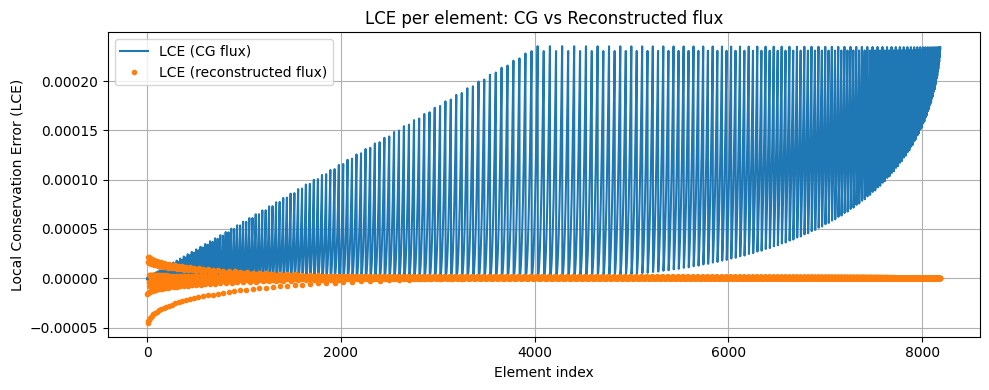

CG LCE stats: {'min': -1.4640558483656574e-06, 'max': 0.0002354064158216206, 'L1_mean_abs': 8.01577336664044e-05, 'L2_rms': 0.00010665911596315128}
Reconstructed LCE stats: {'min': -4.524715012218097e-05, 'max': 2.1960041345825025e-05, 'L1_mean_abs': 9.70070401179564e-07, 'L2_rms': 2.361529788552397e-06}


In [ ]:
# plot
plt.figure(figsize=(10,4))
plt.plot(indices_plot, LCE_CG_plot, label="LCE (CG flux)")
plt.plot(indices_plot, LCE_rec_plot, ".", label="LCE (reconstructed flux)")
plt.xlabel("Element index")
plt.ylabel("Local Conservation Error (LCE)")
# plt.ylim([-0.0,0.012])
plt.title("LCE per element: CG vs Reconstructed flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
# out_path = "/mnt/data/lce_plot.png"
# plt.savefig(out_path)
plt.show()

# print stats & produce dataframe
def stats(arr):
    return {"min": float(arr.min()), "max": float(arr.max()), "L1_mean_abs": float(np.mean(np.abs(arr))), "L2_rms": float(np.sqrt(np.mean(arr**2)))}
print("CG LCE stats:", stats(LCE_CG_plot))
print("Reconstructed LCE stats:", stats(LCE_rec_plot))

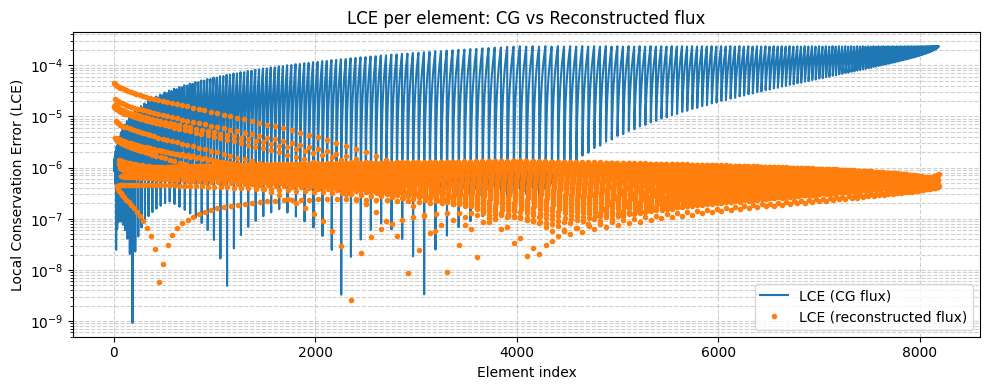

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10,4))
plt.plot(indices_plot, np.abs(LCE_CG_plot), label="LCE (CG flux)")
plt.plot(indices_plot, np.abs(LCE_rec_plot), ".", label="LCE (reconstructed flux)")

plt.xlabel("Element index")
plt.ylabel("Local Conservation Error (LCE)")
plt.title("LCE per element: CG vs Reconstructed flux")

plt.yscale("log")

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from dolfinx import fem, geometry


def flux_errors_with_local_reconstruction(p, p_exact, q_exact, q_rec_global, comm=MPI.COMM_WORLD):

    gdim = omega.geometry.dim
    tdim = omega.topology.dim

    k = order
    deg_flux = max(k - 1, 0)

    Vq = fem.functionspace(omega, ("DG", deg_flux, (gdim,)))

    # ---- CG gradient flux ----
    q_hat = fem.Function(Vq)
    expr = -k_m * ufl.grad(p)
    q_hat.interpolate(
        fem.Expression(expr, Vq.element.interpolation_points)
    )

    # ---- reconstructed flux ----
    q_tilde = q_rec_global

    dx = ufl.dx(domain=omega)

    # --------------------------------------------------
    # Flux errors (reconstructed)
    # --------------------------------------------------
    err_flux = q_exact - q_tilde

    L2_sq_local = fem.assemble_scalar(
        fem.form(ufl.inner(err_flux, err_flux) * dx)
    )
    L2_sq = comm.allreduce(L2_sq_local, op=MPI.SUM)

    Hdiv_sq_local = fem.assemble_scalar(
        fem.form(
            (ufl.inner(err_flux, err_flux)
             + ufl.inner(ufl.div(err_flux), ufl.div(err_flux))) * dx
        )
    )
    Hdiv_sq = comm.allreduce(Hdiv_sq_local, op=MPI.SUM)

    err_L2_flux = np.sqrt(L2_sq)
    err_Hdiv_flux = np.sqrt(Hdiv_sq)

    # --------------------------------------------------
    # Flux error for q_hat
    # --------------------------------------------------
    err_qhat = q_exact - q_hat

    L2_qhat_local = fem.assemble_scalar(
        fem.form(ufl.inner(err_qhat, err_qhat) * dx)
    )
    L2_qhat = comm.allreduce(L2_qhat_local, op=MPI.SUM)
    err_L2_qhat = np.sqrt(L2_qhat)

    # --------------------------------------------------
    # Pressure errors
    # --------------------------------------------------
    err_p = p - p_exact

    L2_p_local = fem.assemble_scalar(
        fem.form(ufl.inner(err_p, err_p) * dx)
    )
    L2_p = comm.allreduce(L2_p_local, op=MPI.SUM)

    H1_p_local = fem.assemble_scalar(
        fem.form(
            (ufl.inner(err_p, err_p)
             + ufl.inner(ufl.grad(err_p), ufl.grad(err_p))) * dx
        )
    )
    H1_p = comm.allreduce(H1_p_local, op=MPI.SUM)

    err_L2_p = np.sqrt(L2_p)
    err_H1_p = np.sqrt(H1_p)

    # --------------------------------------------------
    # Centroid MSE
    # --------------------------------------------------
    num_cells = omega.topology.index_map(tdim).size_local

    cell_centers = np.zeros((gdim, num_cells))

    omega.topology.create_connectivity(tdim, 0)
    cells = omega.topology.connectivity(tdim, 0)

    x = omega.geometry.x

    for c in range(num_cells):
        vertices = cells.links(c)
        coords = x[vertices]
        cell_centers[:, c] = coords.mean(axis=0)[:gdim]

    if gdim == 2:
        pts3 = np.column_stack([cell_centers.T, np.zeros(num_cells)])
    else:
        pts3 = cell_centers.T

    cells_eval = np.arange(num_cells, dtype=np.int32)

    qtilde_vals = q_tilde.eval(pts3, cells_eval)
    qex_vals = q_exact.eval(pts3, cells_eval)
    qhat_vals = q_hat.eval(pts3, cells_eval)

    mse_local = np.mean(np.sum((qex_vals - qtilde_vals)**2, axis=1))
    mse = comm.allreduce(mse_local, op=MPI.SUM) / comm.size

    return {
        "flux_L2": err_L2_flux,
        "flux_Hdiv": err_Hdiv_flux,
        "qhat_L2": err_L2_qhat,
        "p_L2": err_L2_p,
        "p_H1": err_H1_p,
        "centroid_MSE": mse,
        "points": pts3,
        "q_rec": qtilde_vals,
        "q_exact": qex_vals,
        "q_hat": qhat_vals,
    }

In [ ]:
Vq = fem.functionspace(omega, ("DG", 0, (omega.geometry.dim,)))
q = fem.Function(Vq)

def q_exact_expr(x):
    values = np.zeros((2, x.shape[1]))
    values[0] = -x[0] * x[1]**2      # q_x
    values[1] = -2 * x[0]**2 * x[1]  # q_y
    return values

q.interpolate(q_exact_expr)

Vp = fem.functionspace(omega, ("CG", order))
p_ex = fem.Function(Vp)

def p_exact_expr(x):
    return 0.5 * x[0] * x[1]**2

p_ex.interpolate(p_exact_expr)

errors = flux_errors_with_local_reconstruction(
    p_sol,
    p_ex,
    q,
    q_rec_global,
    comm=MPI.COMM_WORLD
)

# print(errors)

In [ ]:
errors["p_L2"], errors["p_H1"]

(np.float64(2.9123911678073728e-05), np.float64(0.0003173315752432223))

In [ ]:
errors["flux_L2"], errors["qhat_L2"], errors["centroid_MSE"]

(np.float64(1.154635549333421),
 np.float64(0.006563467068180336),
 np.float64(1.3331634615589958))